In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding="latin1")

df.shape

(9994, 21)

In [3]:
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [6]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

In [8]:
df[['Order Date', 'Ship Date']].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [9]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter

In [26]:
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

cols_texto = ['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Region', 'Category', 'Sub-Category']
for col in cols_texto:
    df[col] = df[col].str.strip()

ventas_erroneas = df[df['Sales'] <= 0]
print(f"Ventas con valores <= 0: {len(ventas_erroneas)}")

Registros duplicados: 0
Ventas con valores <= 0: 0


In [ ]:
from pathlib import Path

# Profit Margin 
df['Profit Margin'] = df['Profit'] / df['Sales']

# Logistics Efficiency 
df['Days to Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Aggressive Discount Identifier
# Flag any discount greater than 20% as High
df['Discount Level'] = df['Discount'].apply(lambda x: 'High' if x > 0.2 else 'Standard')

# Time Formatting for Visualizations
df['Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)

output_dir = Path("data/processed")

# Create directory if it doesn't exist 
output_dir.mkdir(parents=True, exist_ok=True)

# Define the final output file and save it
output_file = output_dir / "Superstore_Clean.csv"
df.to_csv(output_file, index=False)


In [ ]:
# Preview newly engineered columns
print("--- Sample rows with new KPIs ---")
print(df[['Order ID', 'Profit Margin', 'Days to Ship', 'Discount Level']].head())

# Statistical summary
print("\n--- Profit Margin Statistical Summary ---")
print(df['Profit Margin'].describe())

# Average Profit Margin by Region
print("\n--- Average Profit Margin by Region (Sorted) ---")
print(df.groupby('Region')['Profit Margin'].mean().sort_values())

--- Sample rows with new KPIs ---
         Order ID  Profit Margin  Days to Ship Discount Level
0  CA-2016-152156         0.1600             3       Standard
1  CA-2016-152156         0.3000             3       Standard
2  CA-2016-138688         0.4700             4       Standard
3  US-2015-108966        -0.4000             7           High
4  US-2015-108966         0.1125             7       Standard

--- Profit Margin Statistical Summary ---
count    9994.000000
mean        0.120314
std         0.466754
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

--- Average Profit Margin by Region (Sorted) ---
Region
Central   -0.104073
South      0.163519
East       0.167227
West       0.219487
Name: Profit Margin, dtype: float64


Quantitative Evidence

In [30]:
grouped = df.groupby('Discount Level')

avg_margin = grouped['Profit Margin'].mean() * 100
total_profit = grouped['Profit'].sum()
counts = grouped.size()

print("\n--- PORTFOLIO QUANTITATIVE EVIDENCE ---")

print("\n[ 1. Average Profit Margin ]")
print(f"High Discount:     {avg_margin.get('High', 0):>8.2f}%")
print(f"Standard Discount: {avg_margin.get('Standard', 0):>8.2f}%")

print("\n[ 2. Total Profit (USD) ]")
print(f"High Discount:     ${total_profit.get('High', 0):>10,.2f}")
print(f"Standard Discount: ${total_profit.get('Standard', 0):>10,.2f}")

print("\n[ 3. Transaction Count ]")
print(f"High Discount:     {counts.get('High', 0):>8,} orders")
print(f"Standard Discount: {counts.get('Standard', 0):>8,} orders")


--- PORTFOLIO QUANTITATIVE EVIDENCE ---

[ 1. Average Profit Margin ]
High Discount:       -78.45%
Standard Discount:    26.69%

[ 2. Total Profit (USD) ]
High Discount:     $-135,376.06
Standard Discount: $421,773.08

[ 3. Transaction Count ]
High Discount:        1,393 orders
Standard Discount:    8,601 orders


What if Analyze (ARGETED SIMULATION)

In [ ]:
# Filter: Target only Texas and High Discount transactions
target_df = df[(df['State'] == 'Texas') & (df['Discount'] > 0.2)].copy()

# Prevent division by zero
target_df['Original Price'] = target_df.apply(
    lambda row: row['Sales'] / (1 - row['Discount']) if row['Discount'] < 1 else row['Sales'],
    axis=1
)

# Constant costs base cost remains the same
target_df['Cost'] = target_df['Sales'] - target_df['Profit']

# Discount reduction policy -5%
discount_reduction = 0.05
target_df['Simulated Discount'] = (target_df['Discount'] - discount_reduction).clip(lower=0)

# Calculate new sales and projected profit
target_df['Simulated Sales'] = target_df['Original Price'] * (1 - target_df['Simulated Discount'])
target_df['Simulated Profit'] = target_df['Simulated Sales'] - target_df['Cost']

# Real monetary comparison
current_profit = target_df['Profit'].sum()
simulated_profit = target_df['Simulated Profit'].sum()

impact = simulated_profit - current_profit
impact_pct = (impact / abs(current_profit)) * 100 if current_profit != 0 else 0

print("\n--- WHAT-IF ANALYSIS (TEXAS, HIGH DISCOUNT ONLY) ---")
print(f"Current Profit:   ${current_profit:>12,.2f}")
print(f"Simulated Profit: ${simulated_profit:>12,.2f}")
print(f"Recovered Profit: ${impact:>12,.2f}")
print(f"Improvement:      {impact_pct:>12.2f}%")


--- WHAT-IF ANALYSIS (TEXAS, HIGH DISCOUNT ONLY) ---
Current Profit:   $  -33,955.28
Simulated Profit: $  -24,903.48
Recovered Profit: $    9,051.80
Improvement:             26.66%


KEY VISUALIZATION: Discount vs Profit Margin

C:\Users\arman\AppData\Local\Temp\ipykernel_38044\3378825535.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Discount Bin')['Profit Margin']



Chart saved at: G:\.shortcut-targets-by-id\1I39Y8PlqCF9fqnET1won4j00VQfgJ3Bg\Documentos\GitHub_2026_Rebuild\bi_project_supersotre\Notebooks\images\projects\discount_vs_profit.png


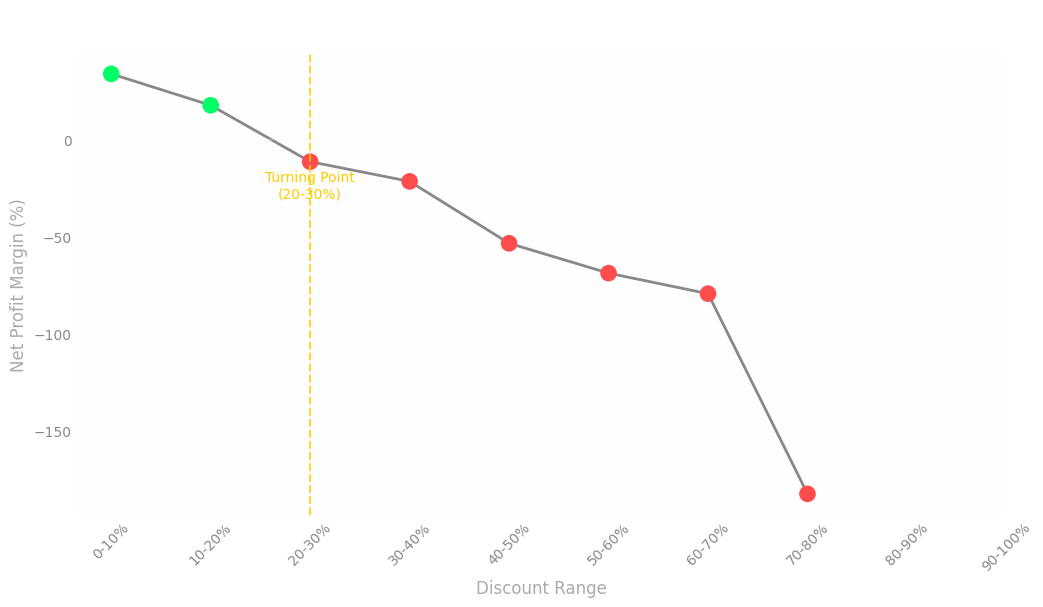

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# CREATE DISCOUNT BINS
bins = np.arange(0, 1.1, 0.1)
labels = [f"{int(b*100)}-{int((b+0.1)*100)}%" for b in bins[:-1]]

df['Discount Bin'] = pd.cut(
    df['Discount'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# AGGREGATE DATA
trend_df = (
    df.groupby('Discount Bin')['Profit Margin']
    .mean()
    .reset_index()
)

trend_df['Profit Margin'] *= 100  # Convert to %

# Create numeric index for plotting
trend_df['Bin Index'] = range(len(trend_df))

# FIND TURNING POINT (FIRST NEGATIVE BIN)
negative_idx = trend_df[trend_df['Profit Margin'] < 0].index[0]
turning_point_x = trend_df.loc[negative_idx, 'Bin Index']

# PLOT SETUP
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_alpha(0.0)
ax.set_facecolor('#111111')

# 5. TREND LINE
ax.plot(
    trend_df['Bin Index'],
    trend_df['Profit Margin'],
    color='#888888',
    linewidth=2,
    zorder=1
)

# 6. SCATTER POINTS (COLOR BY SIGN)
colors = [
    '#00ff66' if val > 0 else '#ff4d4d'
    for val in trend_df['Profit Margin']
]

ax.scatter(
    trend_df['Bin Index'],
    trend_df['Profit Margin'],
    c=colors,
    s=120,
    zorder=2
)

# 7. BREAK-EVEN LINE
ax.axhline(
    0,
    color='white',
    linestyle='--',
    linewidth=1,
    alpha=0.3
)

# 8. TURNING POINT LINE (CENTER OF BIN)
ax.axvline(
    turning_point_x,
    color='#ffcc00',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8
)

# 9. ANNOTATION
turning_label = trend_df.loc[negative_idx, 'Discount Bin']

ax.text(
    turning_point_x,
    -30,
    f"Turning Point\n({turning_label})",
    color='#ffcc00',
    fontsize=10,
    ha='center'
)

# 10. AXIS FORMATTING
ax.set_xticks(trend_df['Bin Index'])
ax.set_xticklabels(trend_df['Discount Bin'], rotation=45)

ax.set_title(
    'Profitability Declines as Discount Levels Increase',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=20
)

ax.set_xlabel('Discount Range', fontsize=12, color='#aaaaaa')
ax.set_ylabel('Net Profit Margin (%)', fontsize=12, color='#aaaaaa')

ax.tick_params(axis='both', colors='#888888', length=0)

# Remove borders
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

# 11. SAVE IMAGE
output_dir = Path("images/projects")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "discount_vs_profit.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

print(f"\nChart saved at: {output_path.resolve()}")

plt.show()